# Phase 4 TrOCR Word-Level OCR and Final Full-Prescription Pipeline

This notebook trains/evaluates the word-level OCR model and runs the final full-prescription inference flow. It is runnable in Kaggle, Colab, or local Jupyter; Kaggle is preferred when Colab GPU quota is exhausted.

## Part A: Word-Level TrOCR Training and Evaluation

1. Load a word-level OCR dataset. The notebook auto-prefers the Kaggle uploaded dataset at `/kaggle/input/handwritten-prescription`, then `data/combined_trocr_word_dataset`, then the earlier custom/BD fallbacks.
2. Fine-tune `microsoft/trocr-base-handwritten` for medicine-name recognition.
3. Evaluate exact-match accuracy, CER, and WER on unaugmented validation/test splits.
4. Save the best model and prediction CSV for thesis reporting.

## Part B: Final Full-Prescription Evaluation Pipeline

The final section runs:

1. preprocessing
2. YOLO handwritten-region detection
3. hybrid line segmentation
4. hybrid word segmentation
5. word-level TrOCR inference
6. drug lexicon matching plus dosage/frequency extraction
7. structured `predictions.csv` / `predictions.json`

Your OCR model is word-level, so final full-prescription inference must segment down to word crops before TrOCR.


In [1]:
# Kaggle/Colab/local project setup.
# Kaggle input dataset expected at:
# /kaggle/input/handwritten-prescription
# Kaggle outputs/checkpoints are written to:
# /kaggle/working/trocr_work

from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/nbl-ahmd/project.git'
IN_KAGGLE = Path('/kaggle/input').exists() or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ
IN_COLAB = ('google.colab' in sys.modules or 'COLAB_GPU' in os.environ) and not IN_KAGGLE

if IN_KAGGLE:
    # Kaggle notebooks run from /kaggle/working. Datasets are read-only under /kaggle/input.
    REPO_DIR = Path.cwd()
    DATA_DIR = Path('/kaggle/input/handwritten-prescription')
    RAW_DIR = DATA_DIR / 'data' / 'raw'
    PROJECT_DIR = Path('/kaggle/working/trocr_work')
elif IN_COLAB:
    from google.colab import drive
    DRIVE_BASE = Path('/content/drive/MyDrive/phase4_project')
    REPO_DIR = DRIVE_BASE / 'repo'
    drive.mount('/content/drive')
    DRIVE_BASE.mkdir(parents=True, exist_ok=True)

    if not (REPO_DIR / 'pipeline').exists():
        if REPO_DIR.exists() and any(REPO_DIR.iterdir()):
            raise RuntimeError(
                f'{REPO_DIR} exists but does not look like the project repo. '
                'Move/rename it or set REPO_DIR to the correct folder.'
            )
        subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(['git', '-C', str(REPO_DIR), 'pull', '--ff-only'], check=False)

    DATA_DIR = REPO_DIR / 'data'
    RAW_DIR = DATA_DIR / 'raw'
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    PROJECT_DIR = DRIVE_BASE / 'trocr_work'
else:
    REPO_DIR = Path.cwd()
    DATA_DIR = REPO_DIR / 'data'
    RAW_DIR = DATA_DIR / 'raw'
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    PROJECT_DIR = REPO_DIR / 'trocr_work'

os.chdir(REPO_DIR)
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

print('IN_KAGGLE:', IN_KAGGLE)
print('IN_COLAB:', IN_COLAB)
print('Repository/workdir:', REPO_DIR)
print('Data folder:', DATA_DIR)
print('Current working directory:', Path.cwd())
print('Has pipeline:', (Path.cwd() / 'pipeline').exists())
print('Raw data folder:', RAW_DIR)
print('TrOCR work folder:', PROJECT_DIR)


IN_KAGGLE: True
IN_COLAB: False
Repository/workdir: /kaggle/working
Data folder: /kaggle/input/handwritten-prescription
Current working directory: /kaggle/working
Has pipeline: False
Raw data folder: /kaggle/input/handwritten-prescription/data/raw
TrOCR work folder: /kaggle/working/trocr_work


## Step 1: Install OCR Dependencies

Run this once at the start of the Kaggle/Colab session. Kaggle may already have some packages, but this keeps versions consistent for TrOCR training and evaluation.


In [2]:
!pip -q install -U transformers datasets evaluate jiwer accelerate sentencepiece kagglehub


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 93.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 107.9 MB/s eta 0:00:0000:01


## Imports


In [ ]:
import os
import random
import inspect
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset

from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    default_data_collator,
    EarlyStoppingCallback,
)
import evaluate

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')
print('Torch:', torch.__version__)


In [3]:
import shutil
shutil.make_archive(
    "/kaggle/working/phase4_trocr_best_model",
    "zip",
    root_dir="/kaggle/working/trocr_work/best_model"
)

'/kaggle/working/phase4_trocr_best_model.zip'

## Optional: Download Original BD Dataset with KaggleHub

Skip this on Kaggle when you attached `nblahmd/handwritten-prescription` as an input dataset. Use this only if the dataset is not already available in Drive/Kaggle input.


In [ ]:
# Optional fallback only. In Kaggle, attach the dataset instead of downloading here.
RUN_KAGGLEHUB_DOWNLOAD = False

if RUN_KAGGLEHUB_DOWNLOAD:
    import kagglehub
    path = kagglehub.dataset_download('mamun1113/doctors-handwritten-prescription-bd-dataset')
    print('Path to dataset files:', path)
    KAGGLE_DATASET_PATH = Path(path)
else:
    print('Skipping KaggleHub download. Using attached/local dataset discovery.')


## Config (T4 Fast Default)
If GPU memory is low, keep this fast setup.


In [ ]:
CFG = {
    'model_name': 'microsoft/trocr-base-handwritten',
    'target_col': 'MEDICINE_NAME',
    'image_col': 'IMAGE',
    'max_target_len': 24,
    # Use real epoch-based training. Do not cap with max_steps for final runs.
    'num_train_epochs': 10,
    'train_batch_size': 8,
    'eval_batch_size': 8,
    'grad_accum_steps': 1,
    'learning_rate': 3e-5,
    'warmup_ratio': 0.1,
    'weight_decay': 0.01,
    'num_beams': 1,
    'early_stopping_patience': 4,
    'freeze_encoder': False,
    'output_dir': str(PROJECT_DIR / 'checkpoints'),
    'best_dir': str(PROJECT_DIR / 'best_model'),
    'pred_csv': str(PROJECT_DIR / 'phase4_test_predictions_trocr.csv'),
    # -1 means Trainer uses num_train_epochs. A positive value overrides epochs.
    'max_steps': -1,
}
CFG


## Optional: Build Combined TrOCR Dataset

On Kaggle, the best option is to attach the already-combined dataset `nblahmd/handwritten-prescription`; then skip rebuilding. The notebook will find it under `/kaggle/input/handwritten-prescription`.

Run the next cell only if the three raw source datasets exist inside the working repo and `data/combined_trocr_word_dataset` is missing.


In [ ]:
COMBINED_TROCR_DATASET = Path('data/combined_trocr_word_dataset')

if IN_KAGGLE:
    print('Kaggle mode: using attached dataset from /kaggle/input when available; not rebuilding into read-only input.')
elif not COMBINED_TROCR_DATASET.exists():
    !python3 pipeline/scripts/combine_trocr_datasets.py \
      --output-root "{COMBINED_TROCR_DATASET}" \
      --overwrite
else:
    print('Combined dataset already exists:', COMBINED_TROCR_DATASET)

print('Local combined dataset path:', COMBINED_TROCR_DATASET.resolve())


## Dataset Discovery

For Kaggle, attach this dataset to the notebook:

```text
https://www.kaggle.com/datasets/nblahmd/handwritten-prescription
```

The notebook first searches `/kaggle/input/handwritten-prescription`, including nested folders, for a dataset containing `Training/Validation/Testing`.


In [ ]:
MANUAL_DATASET_BASE = None

DATA_ROOT_HINTS = [
    '/kaggle/input/handwritten-prescription',
    '/kaggle/input/handwritten-prescription/combined_trocr_word_dataset',
    '/kaggle/input/handwritten-prescription/data/combined_trocr_word_dataset',
    '/kaggle/input/handwritten-prescription/Doctor’s Handwritten Prescription BD dataset',
    '/kaggle/input',
    str(PROJECT_DIR / 'data' / 'combined_trocr_word_dataset'),
    str(DATA_DIR / 'combined_trocr_word_dataset'),
    str(REPO_DIR / 'data' / 'combined_trocr_word_dataset'),
    '/content/drive/MyDrive/phase4_project/repo/data/combined_trocr_word_dataset',
    str(REPO_DIR / 'data' / 'custom_word_ocr_dataset_augmented'),
    str(REPO_DIR / 'data' / 'custom_word_ocr_dataset'),
    str(DATA_DIR / 'custom_word_ocr_dataset_augmented'),
    str(DATA_DIR / 'custom_word_ocr_dataset'),
    '/content/drive/MyDrive/phase4_project/repo/data/custom_word_ocr_dataset_augmented',
    '/content/drive/MyDrive/phase4_project/repo/data/custom_word_ocr_dataset',
    '/content/data/doctors-handwritten-prescription-bd-dataset',
    '/content/drive/MyDrive/data/doctors-handwritten-prescription-bd-dataset',
    '/content/drive/MyDrive',
    str(DATA_DIR),
]
if 'KAGGLE_DATASET_PATH' in globals():
    DATA_ROOT_HINTS += [str(KAGGLE_DATASET_PATH), str(KAGGLE_DATASET_PATH.parent)]


def is_dataset_base(p: Path) -> bool:
    return (
        (p / 'Training' / 'training_labels.csv').exists()
        and (p / 'Validation' / 'validation_labels.csv').exists()
        and (p / 'Testing' / 'testing_labels.csv').exists()
    )


def find_dataset_base(hints):
    if MANUAL_DATASET_BASE:
        m = Path(MANUAL_DATASET_BASE)
        if is_dataset_base(m):
            return m
        print('MANUAL_DATASET_BASE invalid:', m)

    for hint in hints:
        p = Path(hint)
        if not p.exists():
            continue
        if is_dataset_base(p):
            return p
        for cand in p.rglob('*'):
            if cand.is_dir() and is_dataset_base(cand):
                return cand

    for root in ['/kaggle/input', '/content', str(REPO_DIR)]:
        root_path = Path(root)
        if not root_path.exists():
            continue
        for f in glob(str(root_path / '**' / 'training_labels.csv'), recursive=True):
            cand = Path(f).parent.parent
            if is_dataset_base(cand):
                return cand
    return None

DATASET_BASE = find_dataset_base(DATA_ROOT_HINTS)
print('DATASET_BASE:', DATASET_BASE)
if DATASET_BASE is None:
    print('Debug candidates (training_labels.csv):')
    debug_files = []
    for root in ['/kaggle/input', '/content', str(REPO_DIR)]:
        root_path = Path(root)
        if root_path.exists():
            debug_files.extend(glob(str(root_path / '**' / 'training_labels.csv'), recursive=True))
    for f in debug_files[:30]:
        print(f)
    raise FileNotFoundError('Dataset base not found. Set MANUAL_DATASET_BASE.')


In [ ]:
SPLITS = {
    'train': {
        'csv': DATASET_BASE / 'Training' / 'training_labels.csv',
        'img_dir': DATASET_BASE / 'Training' / 'training_words',
    },
    'val': {
        'csv': DATASET_BASE / 'Validation' / 'validation_labels.csv',
        'img_dir': DATASET_BASE / 'Validation' / 'validation_words',
    },
    'test': {
        'csv': DATASET_BASE / 'Testing' / 'testing_labels.csv',
        'img_dir': DATASET_BASE / 'Testing' / 'testing_words',
    },
}

train_df = pd.read_csv(SPLITS['train']['csv'])
val_df = pd.read_csv(SPLITS['val']['csv'])
test_df = pd.read_csv(SPLITS['test']['csv'])

print('train:', train_df.shape, 'val:', val_df.shape, 'test:', test_df.shape)
print('columns:', train_df.columns.tolist())
print('unique medicine names:', train_df[CFG['target_col']].nunique())
train_df.head(3)


In [ ]:
def count_missing(df, img_dir, image_col):
    img_dir = Path(img_dir)
    missing = [x for x in df[image_col].astype(str) if not (img_dir / x).exists()]
    return missing

for split_name, split_obj, df in [
    ('train', SPLITS['train'], train_df),
    ('val', SPLITS['val'], val_df),
    ('test', SPLITS['test'], test_df),
]:
    miss = count_missing(df, split_obj['img_dir'], CFG['image_col'])
    print(split_name, 'missing images:', len(miss))


In [ ]:
sample_df = train_df.sample(8, random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    row = sample_df.iloc[i]
    img = Image.open(SPLITS['train']['img_dir'] / row[CFG['image_col']]).convert('RGB')
    ax.imshow(img)
    ax.set_title(str(row[CFG['target_col']]), fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()


## Model + Processor
Uses updated `generation_config` to avoid recent `transformers` ValueError.


In [ ]:
processor = TrOCRProcessor.from_pretrained(CFG['model_name'])
model = VisionEncoderDecoderModel.from_pretrained(CFG['model_name'])

# token IDs stay in model.config
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.sep_token_id

# generation params must go to generation_config
model.generation_config.max_length = CFG['max_target_len']
model.generation_config.no_repeat_ngram_size = 0
model.generation_config.length_penalty = 1.0
model.generation_config.num_beams = CFG['num_beams']
model.generation_config.early_stopping = CFG['num_beams'] > 1

if CFG.get('freeze_encoder', False):
    for p in model.encoder.parameters():
        p.requires_grad = False
    print('Encoder frozen: training decoder only')
else:
    for p in model.parameters():
        p.requires_grad = True
    print('Encoder unfrozen: full TrOCR fine-tuning')

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters: {trainable:,} / {total:,}')


In [ ]:
class PrescriptionWordOCRDataset(Dataset):
    def __init__(self, df, img_dir, processor, target_col, image_col='IMAGE', max_target_len=24):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.processor = processor
        self.target_col = target_col
        self.image_col = image_col
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(self.img_dir / str(row[self.image_col])).convert('RGB')

        pixel_values = self.processor(images=image, return_tensors='pt').pixel_values.squeeze(0)
        text = str(row[self.target_col]).strip()
        labels = self.processor.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_target_len,
            return_tensors='pt',
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {'pixel_values': pixel_values, 'labels': labels}

train_ds = PrescriptionWordOCRDataset(train_df, SPLITS['train']['img_dir'], processor, CFG['target_col'], CFG['image_col'], CFG['max_target_len'])
val_ds = PrescriptionWordOCRDataset(val_df, SPLITS['val']['img_dir'], processor, CFG['target_col'], CFG['image_col'], CFG['max_target_len'])
test_ds = PrescriptionWordOCRDataset(test_df, SPLITS['test']['img_dir'], processor, CFG['target_col'], CFG['image_col'], CFG['max_target_len'])

print('dataset sizes:', len(train_ds), len(val_ds), len(test_ds))


In [ ]:
cer_metric = evaluate.load('cer')
wer_metric = evaluate.load('wer')

def norm_text(s):
    return ' '.join(str(s).strip().split())

def compute_metrics(pred):
    pred_ids = pred.predictions[0] if isinstance(pred.predictions, tuple) else pred.predictions
    label_ids = pred.label_ids.copy()
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    pred_texts = processor.batch_decode(pred_ids, skip_special_tokens=True)
    label_texts = processor.batch_decode(label_ids, skip_special_tokens=True)

    pred_texts = [norm_text(x) for x in pred_texts]
    label_texts = [norm_text(x) for x in label_texts]

    exact = np.mean([p == y for p, y in zip(pred_texts, label_texts)])
    cer = cer_metric.compute(predictions=pred_texts, references=label_texts)
    wer = wer_metric.compute(predictions=pred_texts, references=label_texts)

    return {'exact_match': float(exact), 'cer': float(cer), 'wer': float(wer)}


In [ ]:
def build_training_args(cfg):
    sig = inspect.signature(Seq2SeqTrainingArguments.__init__).parameters
    args_dict = {
        'output_dir': cfg['output_dir'],
        'predict_with_generate': True,
        'save_strategy': 'epoch',
        'logging_strategy': 'steps',
        'logging_steps': 50,
        'per_device_train_batch_size': cfg['train_batch_size'],
        'per_device_eval_batch_size': cfg['eval_batch_size'],
        'gradient_accumulation_steps': cfg['grad_accum_steps'],
        'num_train_epochs': cfg['num_train_epochs'],
        'learning_rate': cfg['learning_rate'],
        'warmup_ratio': cfg['warmup_ratio'],
        'weight_decay': cfg['weight_decay'],
        'save_total_limit': 2,
        'load_best_model_at_end': True,
        'metric_for_best_model': 'exact_match',
        'greater_is_better': True,
        'fp16': torch.cuda.is_available(),
        'dataloader_num_workers': 2,
        'report_to': 'none',
        'remove_unused_columns': False,
        'seed': SEED,
    }
    if cfg.get('max_steps', -1) is not None and int(cfg.get('max_steps', -1)) > 0:
        args_dict['max_steps'] = int(cfg['max_steps'])
    if 'evaluation_strategy' in sig:
        args_dict['evaluation_strategy'] = 'epoch'
    elif 'eval_strategy' in sig:
        args_dict['eval_strategy'] = 'epoch'
    return Seq2SeqTrainingArguments(**args_dict)

steps_per_epoch = int(np.ceil(len(train_ds) / (CFG['train_batch_size'] * max(1, CFG['grad_accum_steps']))))
planned_steps = steps_per_epoch * CFG['num_train_epochs'] if CFG.get('max_steps', -1) <= 0 else CFG['max_steps']
planned_epochs = planned_steps / max(1, steps_per_epoch)
print('Steps per epoch:', steps_per_epoch)
print('Planned optimizer steps:', planned_steps)
print('Planned epochs:', round(planned_epochs, 2))
print('max_steps:', CFG.get('max_steps'), '(positive max_steps overrides num_train_epochs)')

training_args = build_training_args(CFG)
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CFG['early_stopping_patience'])],
)
training_args


In [ ]:
train_result = trainer.train()
print(train_result)


In [ ]:
val_metrics = trainer.evaluate(eval_dataset=val_ds, metric_key_prefix='val')
test_metrics = trainer.evaluate(eval_dataset=test_ds, metric_key_prefix='test')
print('Validation:', val_metrics)
print('Test:', test_metrics)


In [ ]:
best_dir = Path(CFG['best_dir'])
best_dir.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(best_dir))
processor.save_pretrained(str(best_dir))

# Save run metadata so the demo notebook can report the training configuration.
metadata = {
    'model_name': CFG['model_name'],
    'dataset_base': str(DATASET_BASE),
    'train_samples': int(len(train_df)),
    'validation_samples': int(len(val_df)),
    'test_samples': int(len(test_df)),
    'num_train_epochs': CFG['num_train_epochs'],
    'max_steps': CFG['max_steps'],
    'train_batch_size': CFG['train_batch_size'],
    'eval_batch_size': CFG['eval_batch_size'],
    'grad_accum_steps': CFG['grad_accum_steps'],
    'learning_rate': CFG['learning_rate'],
    'warmup_ratio': CFG['warmup_ratio'],
    'weight_decay': CFG['weight_decay'],
    'freeze_encoder': CFG['freeze_encoder'],
    'best_checkpoint': str(trainer.state.best_model_checkpoint),
    'best_metric': trainer.state.best_metric,
}
import json
(best_dir / 'phase4_training_metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print('Saved best model to:', best_dir)
print('Best checkpoint:', trainer.state.best_model_checkpoint)
print('Best validation exact-match:', trainer.state.best_metric)


In [ ]:
pred = trainer.predict(test_ds)
pred_ids = pred.predictions[0] if isinstance(pred.predictions, tuple) else pred.predictions
pred_texts = [norm_text(x) for x in processor.batch_decode(pred_ids, skip_special_tokens=True)]

pred_df = test_df.copy()
pred_df['PREDICTED_MEDICINE_NAME'] = pred_texts
pred_df['IS_EXACT'] = (
    pred_df[CFG['target_col']].astype(str).map(norm_text) == pred_df['PREDICTED_MEDICINE_NAME']
).astype(int)

pred_csv = Path(CFG['pred_csv'])
pred_csv.parent.mkdir(parents=True, exist_ok=True)
pred_df.to_csv(pred_csv, index=False)
print('Saved predictions to:', pred_csv)
pred_df.head(15)


## Inference (Presentation-Time)
Load model from Drive and predict on a single crop or a folder of crops.


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def load_saved_model(model_dir=None):
    if model_dir is None:
        model_dir = CFG['best_dir']
    proc = TrOCRProcessor.from_pretrained(model_dir)
    mdl = VisionEncoderDecoderModel.from_pretrained(model_dir).to(device)
    mdl.eval()
    return proc, mdl

def predict_single_crop(image_path, proc=None, mdl=None):
    if proc is None or mdl is None:
        proc, mdl = load_saved_model()

    image = Image.open(image_path).convert('RGB')
    pixel_values = proc(images=image, return_tensors='pt').pixel_values.to(device)

    with torch.no_grad():
        gen_ids = mdl.generate(
            pixel_values,
            num_beams=CFG['num_beams'],
            max_length=CFG['max_target_len'],
            early_stopping=(CFG['num_beams'] > 1),
        )
    return norm_text(proc.batch_decode(gen_ids, skip_special_tokens=True)[0])

def predict_folder(folder_path, exts=('.png', '.jpg', '.jpeg', '.webp')):
    proc, mdl = load_saved_model()
    rows = []
    for p in sorted(Path(folder_path).iterdir()):
        if p.suffix.lower() in exts:
            rows.append({'file': p.name, 'prediction': predict_single_crop(p, proc, mdl)})
    return pd.DataFrame(rows)



In [ ]:
# Example inference
# print(predict_single_crop('/content/some_crop.png'))
# df_pred = predict_folder('/content/some_folder_with_crops')
# df_pred.head()


In [ ]:
# Save/export artifacts.
# Kaggle cannot directly write to Google Drive unless you configure Drive credentials/rclone.
# The reliable Kaggle workflow is:
# 1. Save best_model in /kaggle/working/trocr_work/best_model
# 2. Create /kaggle/working/phase4_trocr_best_model.zip
# 3. Download it from Kaggle Output
# 4. Upload/unzip it to Google Drive: /content/drive/MyDrive/phase4_project/trocr_work/best_model

import shutil
from pathlib import Path

best_dir = Path(CFG['best_dir'])
zip_base = Path('/kaggle/working/phase4_trocr_best_model') if IN_KAGGLE else PROJECT_DIR / 'phase4_trocr_best_model'
zip_path = shutil.make_archive(str(zip_base), 'zip', root_dir=str(best_dir))
print('Best model folder:', best_dir)
print('Zipped model artifact:', zip_path)
print('Prediction CSV:', CFG['pred_csv'])

if IN_COLAB:
    print('Model is already saved in Google Drive at:', best_dir)
    print('Zip is saved at:', zip_path)
elif IN_KAGGLE:
    print('Kaggle: open the notebook Output panel and download phase4_trocr_best_model.zip')
    print('Then upload/unzip it to Drive path: /content/drive/MyDrive/phase4_project/trocr_work/best_model')
else:
    print('Local run: copy the best_model folder or zip to your preferred backup location.')


## Final Evaluation: Full Prescription Pipeline

This section runs the final thesis pipeline:

1. preprocess full prescription pages
2. detect handwritten regions with `models/region_yolo_best.pt`
3. segment lines using the hybrid OpenCV line segmenter
4. segment word crops
5. run word-level TrOCR
6. apply lexicon matching and dosage/frequency extraction

Do not pass the weak YOLO line model here unless you are doing an ablation experiment.


In [ ]:
from pathlib import Path
import os

# Reuse the Drive-backed repo created in the setup cell.
os.chdir(REPO_DIR)
print('REPO_DIR:', REPO_DIR)
print('Has pipeline:', Path('pipeline').exists())
print('Raw prescription folder:', Path('data/raw').resolve())
print('Raw images:', len([p for p in Path('data/raw').glob('*') if p.is_file()]))

### Install Pipeline Dependencies
Use the core requirements for preprocessing, segmentation, and annotation packaging. Install the OCR requirements only when running TrOCR inference locally.


In [ ]:
# Core CV/data pipeline dependencies
# !python3 -m pip install -r pipeline/requirements.txt

# Optional: local TrOCR inference dependencies
# !python3 -m pip install -r pipeline/requirements-ocr.txt


### Step 1: Preprocess Full Prescription Images
Input folder: `data/raw`.
Output folder: `data/processed/pages`.


In [ ]:
!python3 pipeline/scripts/preprocess_pages.py \
  --input-dir data/raw \
  --output-dir data/processed/pages \
  --manifest-out data/processed/page_manifest.csv


### Step 2: Prepare Layout Annotation Package
This creates images/classes for CVAT or Label Studio. Annotate `header`, `handwritten_region`, and `footer`, then export YOLO labels into `data/processed/layout_yolo_labels`.


In [ ]:
!python3 pipeline/scripts/prepare_layout_annotation.py \
  --pages-dir data/processed/pages \
  --output-dir data/processed/layout_annotation_package \
  --copy-images

print('Next manual step: annotate package images in CVAT/Label Studio and export YOLO labels to data/processed/layout_yolo_labels')


### Step 3: Crop Handwritten Regions
Run after YOLO layout labels are available. These region crops isolate prescription handwriting from printed header/footer content.


In [ ]:
!python3 pipeline/scripts/crop_regions_from_yolo.py \
  --pages-dir data/processed/pages \
  --labels-dir data/processed/layout_yolo_labels \
  --class-map pipeline/config/layout_classes.txt \
  --target-label handwritten_region \
  --output-dir data/processed/regions \
  --manifest-out data/processed/region_manifest.csv


### Step 4: Segment Lines from Handwritten Regions
This creates line crops for each medication/instruction line and context images for review.


In [ ]:
!python3 pipeline/scripts/segment_lines.py \
  --region-manifest data/processed/region_manifest.csv \
  --output-dir data/processed/line_crops \
  --manifest-out data/processed/line_manifest.csv


### Step 5: Segment Word Crops for Word-Level Annotation
This produces word images similar to the previously used BD cropped-word dataset.


In [ ]:
!python3 pipeline/scripts/segment_words.py \
  --line-manifest data/processed/line_manifest.csv \
  --output-dir data/processed/word_crops \
  --manifest-out data/processed/word_manifest.csv


### Step 6: Create Word Annotation Sheet
Annotate `word_text`, `medicine_name`, `is_medicine`, and `review_status`. Use the Streamlit app locally for visual annotation.


In [ ]:
!python3 pipeline/scripts/create_word_annotation_manifest.py \
  --word-manifest data/processed/word_manifest.csv \
  --output-csv data/processed/word_annotations.csv

print('Local app command:')
print('streamlit run pipeline/app/word_annotator_app.py -- --manifest data/processed/word_manifest.csv --annotations data/processed/word_annotations.csv --annotator-id annotator_1')


### Step 7: Build Custom Word-Level OCR Dataset
After reviewing annotations, export medicine word crops to the same structure as the BD dataset:

- `Training/training_words/*.png`
- `Validation/validation_words/*.png`
- `Testing/testing_words/*.png`
- split label CSV files with `IMAGE,MEDICINE_NAME`


In [ ]:
!python3 pipeline/scripts/build_ocr_dataset.py \
  --annotations-csv data/processed/word_annotations.csv \
  --output-root data/custom_word_ocr_dataset \
  --image-path-column word_image_path \
  --label-column medicine_name \
  --approved-status reviewed \
  --seed 42

CUSTOM_DATASET_BASE = Path('data/custom_word_ocr_dataset')
print('CUSTOM_DATASET_BASE:', CUSTOM_DATASET_BASE)


### Step 8: Train/Fine-Tune TrOCR on the Combined Word Dataset

For Kaggle, the Dataset Discovery cell should already select `/kaggle/input/handwritten-prescription/...`. If needed, set `MANUAL_DATASET_BASE` manually to the exact attached dataset folder before rerunning Dataset Discovery.


In [ ]:
# Use this before rerunning the earlier Dataset Discovery cell, if auto-discovery fails.
preferred_dataset = Path('/kaggle/input/handwritten-prescription')
if not preferred_dataset.exists():
    preferred_dataset = Path('data/combined_trocr_word_dataset')
if not preferred_dataset.exists():
    preferred_dataset = Path('data/custom_word_ocr_dataset_augmented')
if not preferred_dataset.exists():
    preferred_dataset = Path('data/custom_word_ocr_dataset')
MANUAL_DATASET_BASE = str(preferred_dataset.resolve())
print('MANUAL_DATASET_BASE =', MANUAL_DATASET_BASE)


### Step 9: Final End-to-End Inference

This command runs raw full prescriptions through preprocessing, trained region YOLO, hybrid line/word segmentation, TrOCR inference, and lexicon validation. Use your fine-tuned checkpoint path for `TROCR_MODEL`.


In [ ]:
# Replace this with your saved/fine-tuned checkpoint when available.
# Example Kaggle checkpoint: '/kaggle/working/trocr_work/best_model'
REGION_MODEL = Path('models/region_yolo_best.pt')
trained_checkpoint = Path(CFG['output_dir']) / 'best_model'
TROCR_MODEL = str(trained_checkpoint) if trained_checkpoint.exists() else 'microsoft/trocr-base-handwritten'

print('Region model:', REGION_MODEL.resolve(), REGION_MODEL.exists())
print('TrOCR model:', TROCR_MODEL)

!python3 pipeline/scripts/run_end_to_end.py \
  --input data/raw \
  --output-dir data/final_demo_trocr \
  --yolo-model "{REGION_MODEL}" \
  --target-class 0 \
  --ocr-backend trocr \
  --ocr-unit word \
  --trocr-model "{TROCR_MODEL}" \
  --line-padding 6 \
  --lexicon pipeline/config/drug_lexicon.txt


### Step 10: View Structured Output
The final output table contains OCR text, medicine lexicon match, dosage, frequency, and validation status.


In [ ]:
import pandas as pd
pred_path = Path('data/final_demo_trocr/predictions.csv')
if pred_path.exists():
    display(pd.read_csv(pred_path).head(20))
else:
    print('Predictions not found yet:', pred_path)


### Quick Post-OCR Validation Test
This pure text test is useful to show lexicon correction and dosage/frequency parsing even before running the image pipeline.


In [ ]:
!python3 pipeline/scripts/validate_prescription_text.py --text "Acita 650 mg BD"


In [20]:
# Full prescription inference using saved TrOCR model in this Kaggle notebook

from pathlib import Path
import subprocess
import pandas as pd
from IPython.display import display, Image as IPImage

TROCR_MODEL = Path("/kaggle/working/trocr_work/best_model")
INPUT_PATH = Path("/kaggle/input/datasets/nblahmd/input-images/")
OUTPUT_DIR = Path("/kaggle/working/full_pipeline_inference_demo")
REGION_MODEL = Path("models/region_yolo_best.pt")
LEXICON_PATH = Path("pipeline/config/drug_lexicon.txt")

INPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("TrOCR model:", TROCR_MODEL, "exists =", TROCR_MODEL.exists())
print("Input folder:", INPUT_PATH)
print("Output folder:", OUTPUT_DIR)
print("Region model:", REGION_MODEL, "exists =", REGION_MODEL.exists())

if not TROCR_MODEL.exists():
    raise FileNotFoundError("TrOCR best_model not found. Train/save the model first.")

print("\nPut full prescription images inside:")
print(INPUT_PATH)
print("\nThen run this cell again.")

TrOCR model: /kaggle/working/trocr_work/best_model exists = True
Input folder: /kaggle/input/datasets/nblahmd/input-images
Output folder: /kaggle/working/full_pipeline_inference_demo
Region model: models/region_yolo_best.pt exists = False

Put full prescription images inside:
/kaggle/input/datasets/nblahmd/input-images

Then run this cell again.


Images found: 7
/kaggle/input/datasets/nblahmd/input-images/1.jpg
/kaggle/input/datasets/nblahmd/input-images/2.jpg
/kaggle/input/datasets/nblahmd/input-images/3.jpg
/kaggle/input/datasets/nblahmd/input-images/4.jpg
/kaggle/input/datasets/nblahmd/input-images/5.jpg
/kaggle/input/datasets/nblahmd/input-images/6.jpg
/kaggle/input/datasets/nblahmd/input-images/7.jpg


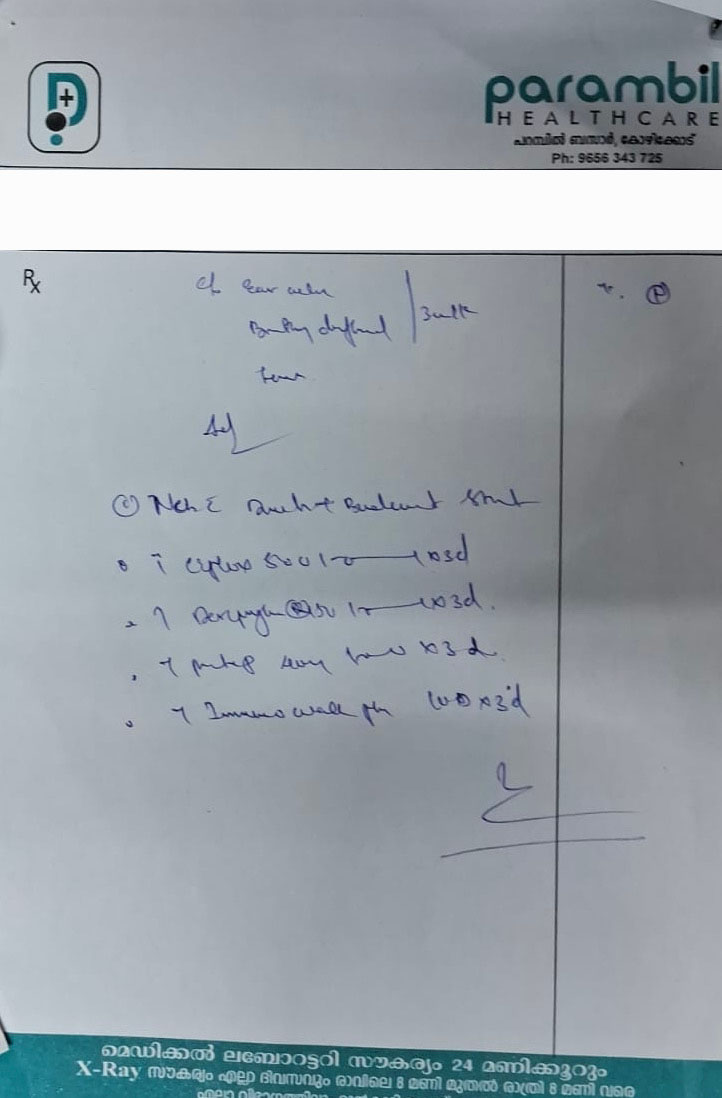

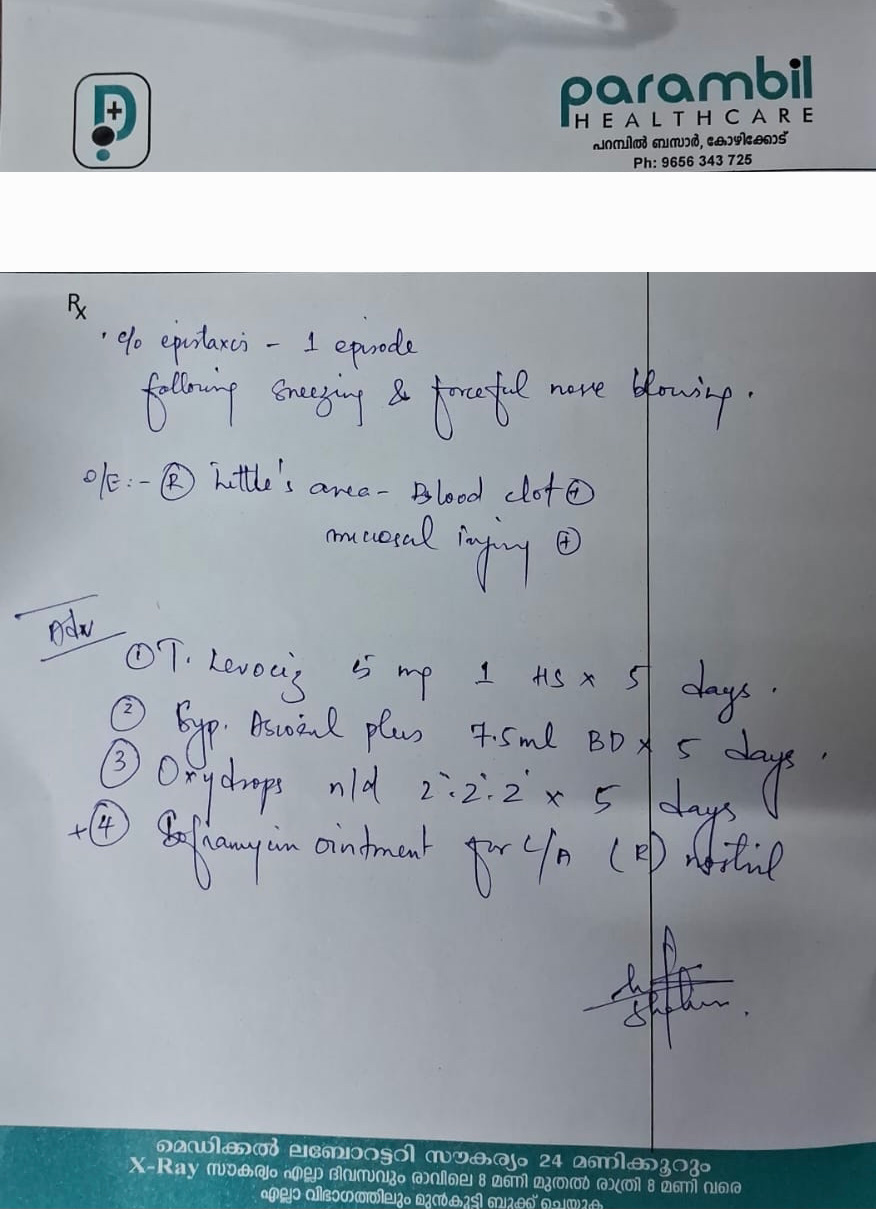

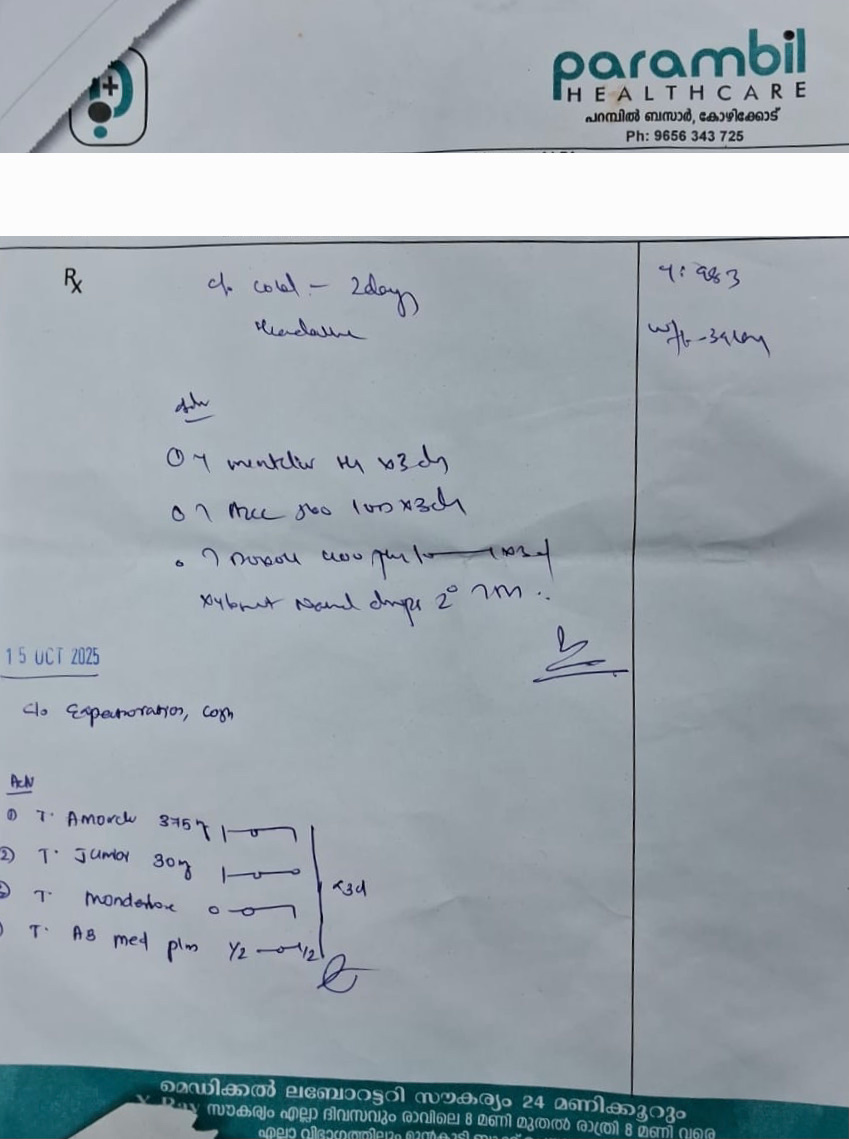

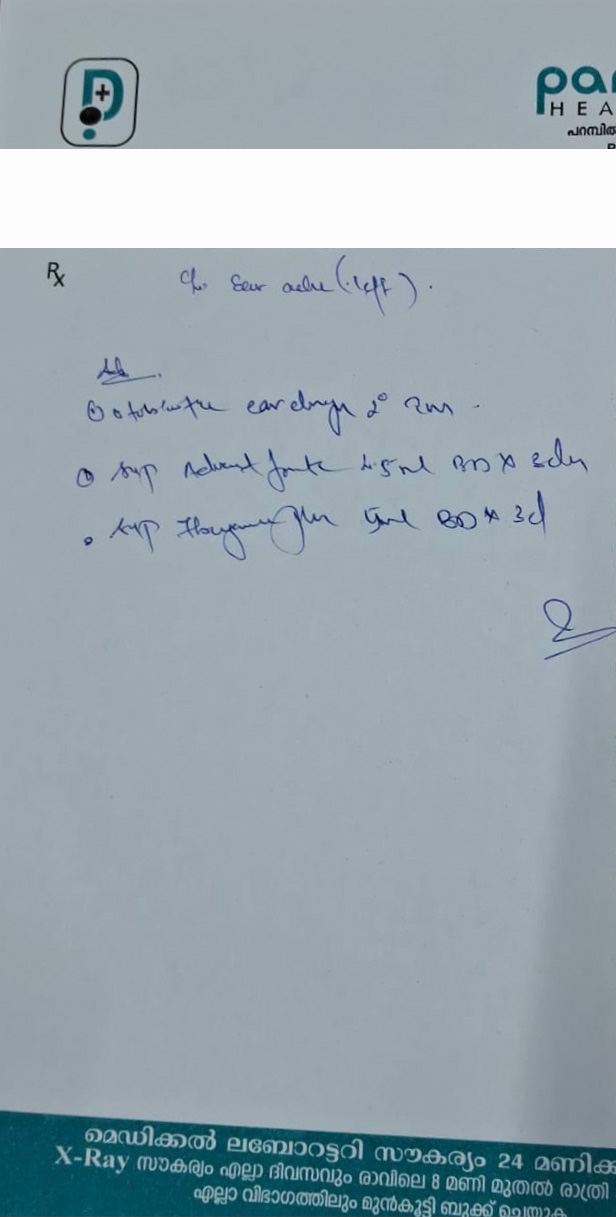

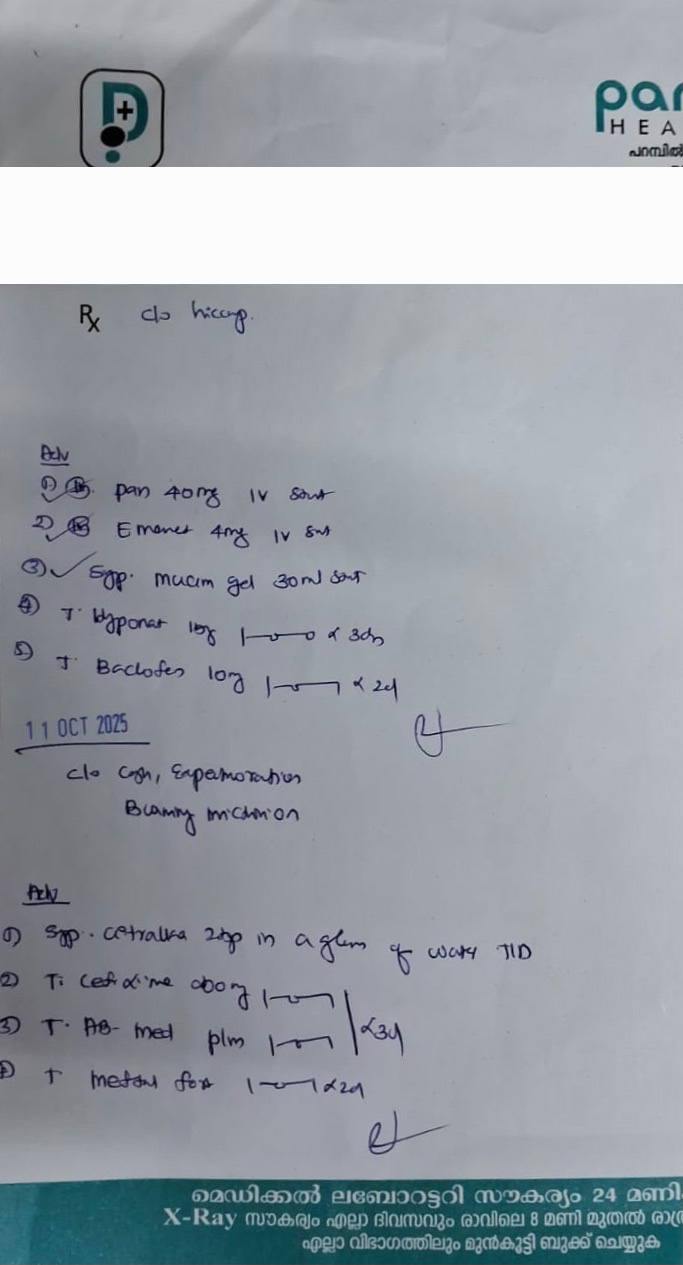

In [21]:
from pathlib import Path
from IPython.display import display, Image as IPImage

INPUT_PATH = Path("/kaggle/input/datasets/nblahmd/input-images")
INPUT_PATH.mkdir(parents=True, exist_ok=True)

image_files = [
    p for p in sorted(INPUT_PATH.glob("*"))
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"]
]

print("Images found:", len(image_files))
for p in image_files:
    print(p)

for p in image_files[:5]:
    display(IPImage(filename=str(p), width=600))

In [22]:
# Run full pipeline: full image -> region -> line -> word -> TrOCR OCR -> lexicon validation

cmd = [
    "python3", "pipeline/scripts/run_end_to_end.py",
    "--input", str(INPUT_PATH),
    "--output-dir", str(OUTPUT_DIR),
    "--ocr-backend", "trocr",
    "--ocr-unit", "word",
    "--trocr-model", str(TROCR_MODEL),
    "--line-padding", "6",
    "--max-side", "1600",
    "--lexicon", str(LEXICON_PATH),
]

if REGION_MODEL.exists():
    cmd += ["--yolo-model", str(REGION_MODEL), "--target-class", "0"]
else:
    print("Region YOLO model not found. Using heuristic region proposal fallback.")

print("Running:")
print(" ".join(cmd))

subprocess.run(cmd, check=True)

print("\nDone.")
print("Predictions:", OUTPUT_DIR / "predictions.csv")
print("Overview images:", OUTPUT_DIR / "segmentation_overview")

Region YOLO model not found. Using heuristic region proposal fallback.
Running:
python3 pipeline/scripts/run_end_to_end.py --input /kaggle/input/datasets/nblahmd/input-images --output-dir /kaggle/working/full_pipeline_inference_demo --ocr-backend trocr --ocr-unit word --trocr-model /kaggle/working/trocr_work/best_model --line-padding 6 --max-side 1600 --lexicon pipeline/config/drug_lexicon.txt


python3: can't open file '/kaggle/working/pipeline/scripts/run_end_to_end.py': [Errno 2] No such file or directory


CalledProcessError: Command '['python3', 'pipeline/scripts/run_end_to_end.py', '--input', '/kaggle/input/datasets/nblahmd/input-images', '--output-dir', '/kaggle/working/full_pipeline_inference_demo', '--ocr-backend', 'trocr', '--ocr-unit', 'word', '--trocr-model', '/kaggle/working/trocr_work/best_model', '--line-padding', '6', '--max-side', '1600', '--lexicon', 'pipeline/config/drug_lexicon.txt']' returned non-zero exit status 2.

TrOCR model: /kaggle/working/trocr_work/best_model exists = True
Input crop folder: /kaggle/input/datasets/nblahmd/handwritten-prescription/combined_trocr_word_dataset/Testing/testing_words exists = True
Images found: 1040


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

  0%|          | 0/1040 [00:00<?, ?it/s]

Saved: /kaggle/working/trocr_only_predictions.csv


,image,filename,prediction
0,/kaggle/input/datasets/nblahmd/handwritten-pre...,000000_rxhand.jpg,Ecosprin
1,/kaggle/input/datasets/nblahmd/handwritten-pre...,000001_rxhand.jpg,Neuroxen
2,/kaggle/input/datasets/nblahmd/handwritten-pre...,000002_bd_training.png,Montair
3,/kaggle/input/datasets/nblahmd/handwritten-pre...,000003_bd_testing.png,Ketoral
4,/kaggle/input/datasets/nblahmd/handwritten-pre...,000004_rxhand.jpg,Fenix-V
...,...,...,...
1035,/kaggle/input/datasets/nblahmd/handwritten-pre...,001035_rxhand.jpg,Asynta
1036,/kaggle/input/datasets/nblahmd/handwritten-pre...,001036_bd_training.png,Bognth
1037,/kaggle/input/datasets/nblahmd/handwritten-pre...,001037_rxhand.jpg,torax
1038,/kaggle/input/datasets/nblahmd/handwritten-pre...,001038_rxhand.jpg,Calboral Dx



Preview:
000000_rxhand.jpg -> Ecosprin


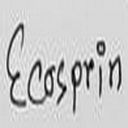

000001_rxhand.jpg -> Neuroxen


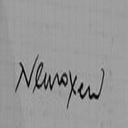

000002_bd_training.png -> Montair


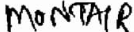

000003_bd_testing.png -> Ketoral


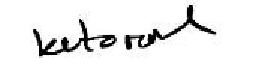

000004_rxhand.jpg -> Fenix-V


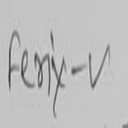

000005_rxhand.jpg -> Anitip


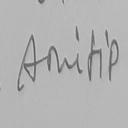

000006_bd_training.png -> Filmet


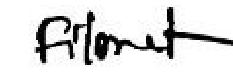

000007_rxhand.jpg -> solupred


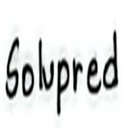

000008_rxhand.jpg -> 5% dns


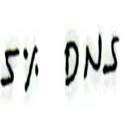

000009_bd_validation.png -> Bacaid


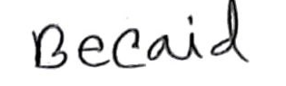

000010_rxhand.jpg -> Alcet


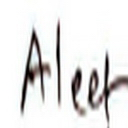

000011_rxhand.jpg -> visef


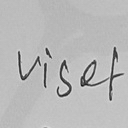

000012_bd_testing.png -> Romycin


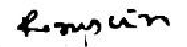

000013_rxhand.jpg -> omeprazole


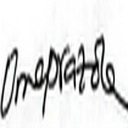

000014_bd_training.png -> Amodis


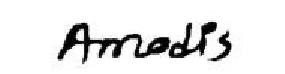

000015_rxhand.jpg -> Tablet


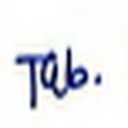

000016_bd_testing.png -> Amodis


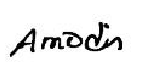

000017_bd_training.png -> Bacaid


000018_rxhand.jpg -> Napa


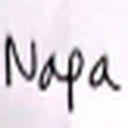

000019_rxhand.jpg -> Calcor-D


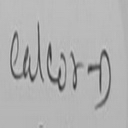

In [24]:
# TrOCR-only inference on cropped word images

from pathlib import Path
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from IPython.display import display, Image as IPImage

TROCR_MODEL = Path("/kaggle/working/trocr_work/best_model")
INPUT_CROPS_DIR = Path("/kaggle/input/datasets/nblahmd/handwritten-prescription/combined_trocr_word_dataset/Testing/testing_words")  # change to your word-crop folder
OUTPUT_CSV = Path("/kaggle/working/trocr_only_predictions.csv")

MAX_TARGET_LEN = 48
NUM_BEAMS = 1

print("TrOCR model:", TROCR_MODEL, "exists =", TROCR_MODEL.exists())
print("Input crop folder:", INPUT_CROPS_DIR, "exists =", INPUT_CROPS_DIR.exists())

if not TROCR_MODEL.exists():
    raise FileNotFoundError(f"Model not found: {TROCR_MODEL}")

image_files = [
    p for p in sorted(INPUT_CROPS_DIR.glob("*"))
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"]
]

print("Images found:", len(image_files))
if not image_files:
    raise FileNotFoundError(f"No images found in {INPUT_CROPS_DIR}")

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = TrOCRProcessor.from_pretrained(str(TROCR_MODEL))
model = VisionEncoderDecoderModel.from_pretrained(str(TROCR_MODEL)).to(device)
model.eval()

def normalize_text(text):
    return " ".join(str(text).strip().split())

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values,
            max_length=MAX_TARGET_LEN,
            num_beams=NUM_BEAMS,
            early_stopping=NUM_BEAMS > 1,
        )

    return normalize_text(
        processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    )

rows = []
for image_path in tqdm(image_files):
    pred = predict_image(image_path)
    rows.append({
        "image": str(image_path),
        "filename": image_path.name,
        "prediction": pred,
    })

pred_df = pd.DataFrame(rows)
pred_df.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
display(pred_df)

print("\nPreview:")
for _, row in pred_df.head(20).iterrows():
    print(row["filename"], "->", row["prediction"])
    display(IPImage(filename=row["image"], width=220))